# Data Integration
**Team:** Sage Kim & Kyna Tyagi

**Research Questions:**
1. How does agricultural production relate to economic development across countries?
2. Do countries with higher cereal production tend to have higher GDP per capita?
3. Has agricultural production growth contributed to economic growth over time?

## 0. Load Libraries & Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../data/processed/merged_cereal_gdp.csv')

print('Shape:', df.shape)
print('Countries:', df['Country'].nunique())
print('Year range:', df['Year'].min(), '~', df['Year'].max())
df.head()

Shape: (2393, 6)
Countries: 66
Year range: 1961 ~ 2024


,Country,Year,Cereal_Production_Value,Flag,Flag Description,GDP_per_capita_USD
0,Argentina,1961,16000.0,A,Official figure,971.338043
1,Argentina,1962,14000.0,A,Official figure,870.217491
2,Argentina,1963,15000.0,A,Official figure,852.972425
3,Argentina,1964,17000.0,A,Official figure,1176.200862
4,Argentina,1965,20000.0,A,Official figure,1281.833380


## Q1. How does agricultural production relate to economic development across countries?

In [3]:
df_q1 = df[['Cereal_Production_Value', 'GDP_per_capita_USD']].dropna()

corr = df_q1['Cereal_Production_Value'].corr(df_q1['GDP_per_capita_USD'])
print('Correlation between Cereal Production and GDP per capita:', round(corr, 4))

Correlation between Cereal Production and GDP per capita: -0.0569


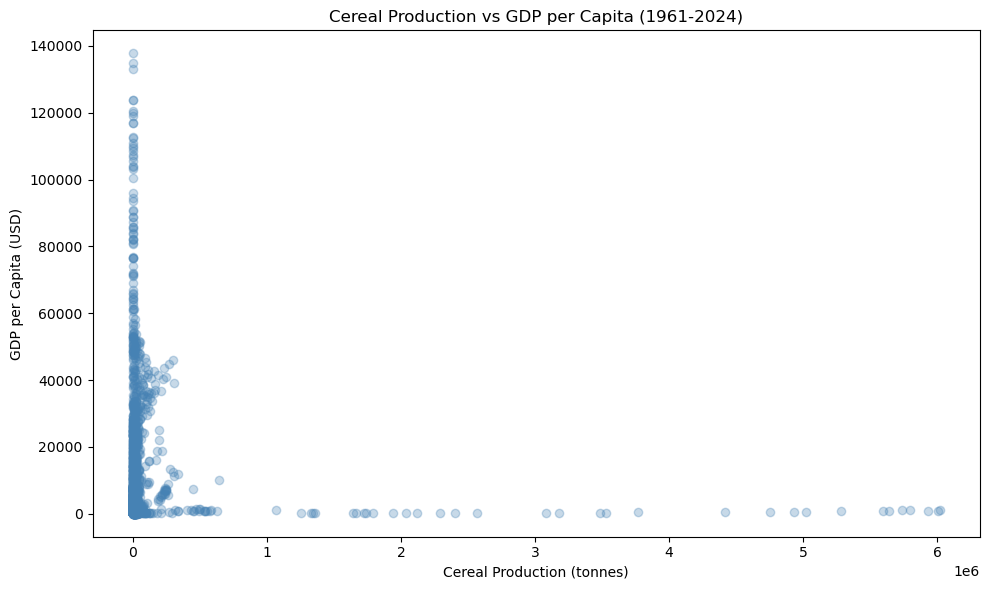

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(df_q1['Cereal_Production_Value'], df_q1['GDP_per_capita_USD'], alpha=0.3, color='steelblue')
plt.xlabel('Cereal Production (tonnes)')
plt.ylabel('GDP per Capita (USD)')
plt.title('Cereal Production vs GDP per Capita (1961-2024)')
plt.tight_layout()
plt.savefig('../analysis/q1_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Q2. Do countries with higher cereal production tend to have higher GDP per capita?

In [5]:
country_avg = df.groupby('Country').agg(
    avg_production=('Cereal_Production_Value', 'mean'),
    avg_gdp=('GDP_per_capita_USD', 'mean')
).dropna()

median_production = country_avg['avg_production'].median()
country_avg['group'] = country_avg['avg_production'].apply(
    lambda x: 'High Production' if x >= median_production else 'Low Production'
)

group_gdp = country_avg.groupby('group')['avg_gdp'].mean()
print('Average GDP per capita by production group:')
group_gdp

Average GDP per capita by production group:


group
High Production    11491.917230
Low Production     16565.122259
Name: avg_gdp, dtype: float64

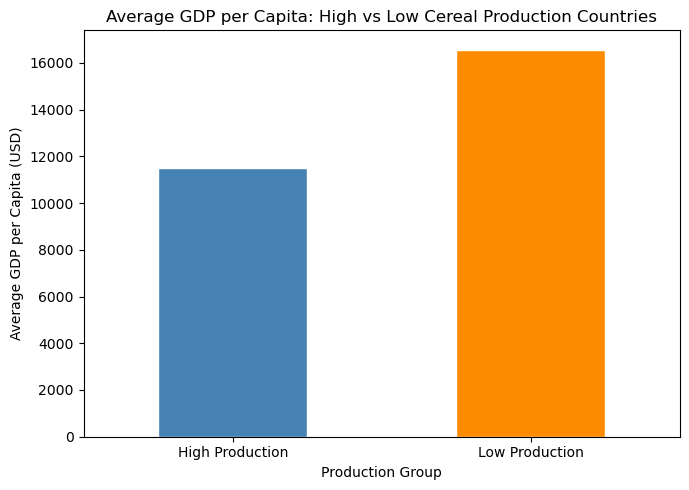

In [6]:
plt.figure(figsize=(7, 5))
group_gdp.plot(kind='bar', color=['steelblue', 'darkorange'], edgecolor='white')
plt.xlabel('Production Group')
plt.ylabel('Average GDP per Capita (USD)')
plt.title('Average GDP per Capita: High vs Low Cereal Production Countries')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../analysis/q2_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Q3. Has agricultural production growth contributed to economic growth over time?

In [7]:
yearly = df.groupby('Year').agg(
    avg_production=('Cereal_Production_Value', 'mean'),
    avg_gdp=('GDP_per_capita_USD', 'mean')
).dropna()

yearly.head()

,avg_production,avg_gdp
Year,,
1961,7335.0,417.445257
1962,7822.9,431.535597
1963,8752.0,461.655550
1964,9746.5,507.422293
1965,13408.9,478.698272


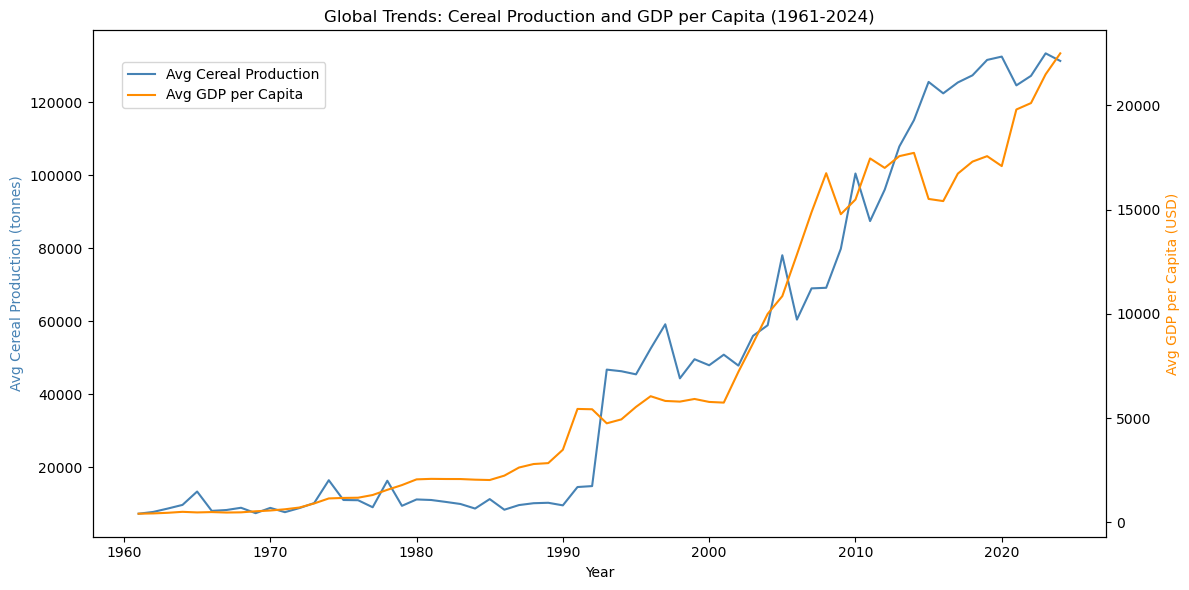

In [8]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(yearly.index, yearly['avg_production'], color='steelblue', label='Avg Cereal Production')
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg Cereal Production (tonnes)', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['avg_gdp'], color='darkorange', label='Avg GDP per Capita')
ax2.set_ylabel('Avg GDP per Capita (USD)', color='darkorange')

plt.title('Global Trends: Cereal Production and GDP per Capita (1961-2024)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig('../analysis/q3_trend.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/1n/v1967xc56_5gwnz6yw_lx0mr0000gn/T/ipykernel_3633/2321547934.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_time = df.groupby('Year').apply(


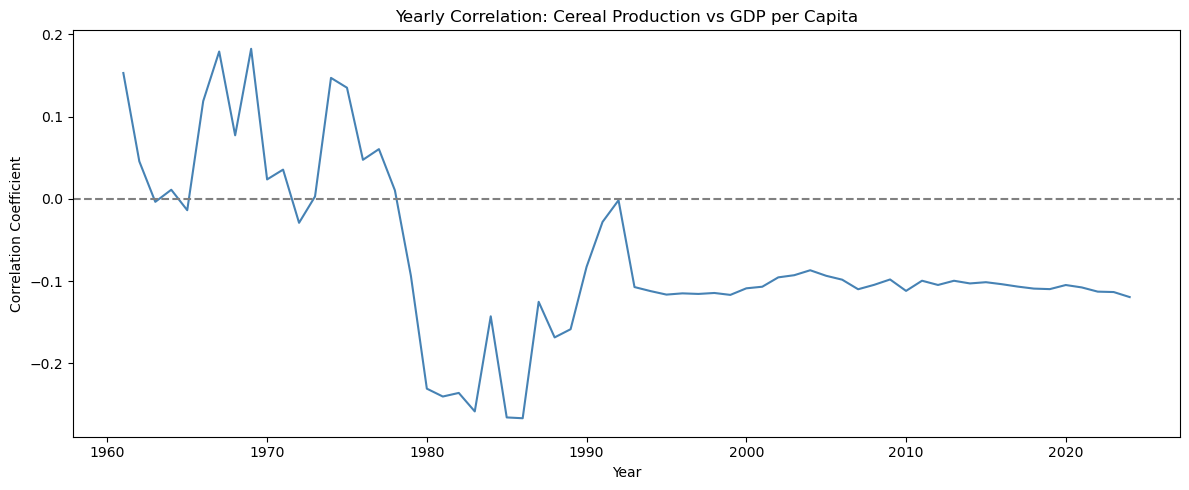

In [10]:
corr_time = df.groupby('Year').apply(
    lambda x: x['Cereal_Production_Value'].corr(x['GDP_per_capita_USD'])
).dropna()

plt.figure(figsize=(12, 5))
plt.plot(corr_time.index, corr_time.values, color='steelblue')
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel('Year')
plt.ylabel('Correlation Coefficient')
plt.title('Yearly Correlation: Cereal Production vs GDP per Capita')
plt.tight_layout()
plt.savefig('../analysis/q3_correlation_over_time.png', dpi=150, bbox_inches='tight')
plt.show()